In [50]:
import pickle
import importlib
import pandas as pd
import numpy as np

import src.utils.dataLoader as data_loader
importlib.reload(data_loader)
from src.utils.dataLoader import DataLoader
import src.utils.state as state
import src.utils.plottings as plotting
import src.utils.scenarioCalculator as scenarioCalculator
import src.utils.dataConverter as dataConverter
import src.utils.config as config
from src.utils.config import GlobalConfig
from src.utils.scenarios import Scenarios
#from src.utils.models import Scenario
import src.utils.projectInitializer as projectInitializer
import src.utils.modelBase as modelBase
import src.utils.models as models

importlib.reload(models)
importlib.reload(plotting)
importlib.reload(state)
importlib.reload(scenarioCalculator)
importlib.reload(dataConverter)
importlib.reload(config)


<module 'src.utils.config' from 'C:\\Users\\CSURITA\\PycharmProjects\\PythonProject\\counterfactual-analysis-vzv\\src\\utils\\config.py'>

In [51]:
Scenario = models.Scenario
ALL_SCENARIOS: list[Scenario] = []

In [52]:
loader = DataLoader()
loader.load_data()
projectInitializer.init_all(loader)
modelBase.calculate_baseline()

## Calculate mean during covid

In [53]:
mean_remainders: np.ndarray[float] = scenarioCalculator.estimate_rt_during_covid(state.REMAINDERS, state.WEEKLY_INDEX)
state.set_mean_remainders(mean_remainders)
mean_births: np.ndarray[float] = scenarioCalculator.calculate_mean_during_covid(state.BIRTH_MATRIX, state.WEEKLY_INDEX)
state.set_no_covid_births(state.BIRTH_MATRIX)
mean_deaths: np.ndarray[float] = scenarioCalculator.calculate_mean_during_covid(state.DEATHS_MATRIX, state.WEEKLY_INDEX)
state.set_no_covid_deaths(mean_deaths)

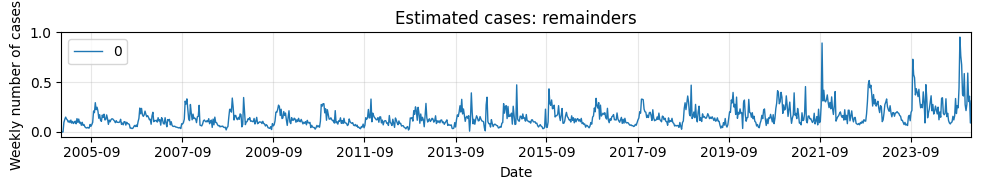

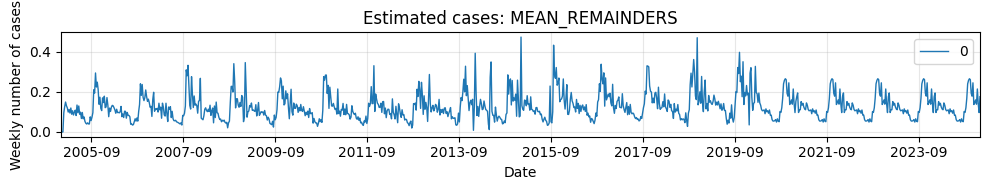

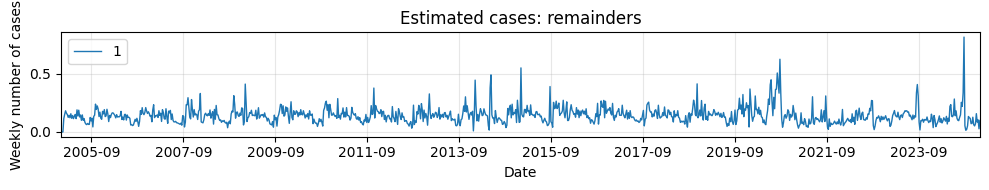

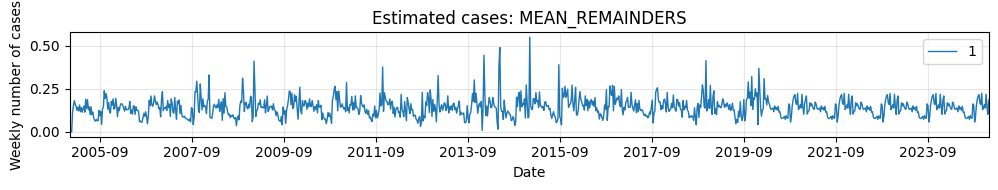

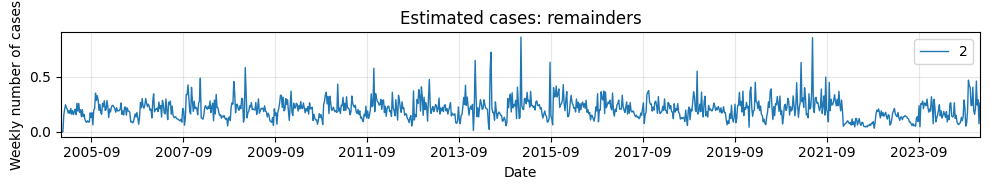

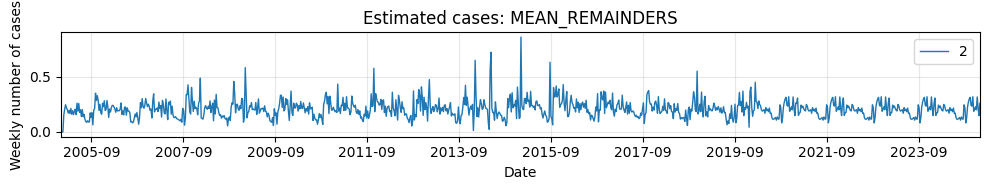

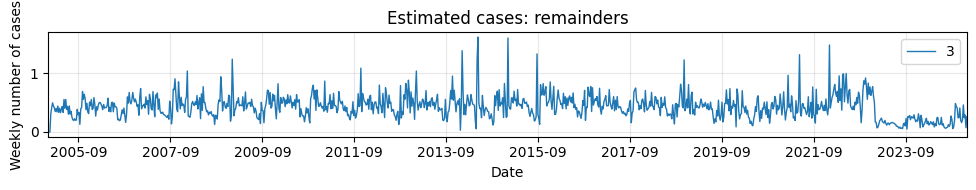

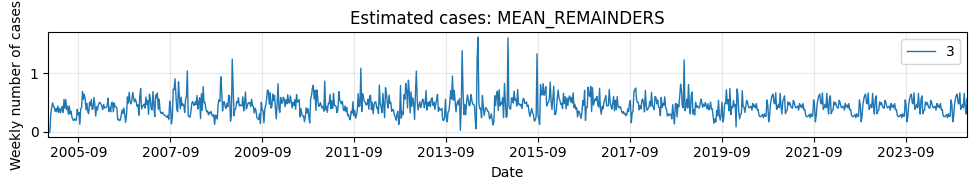

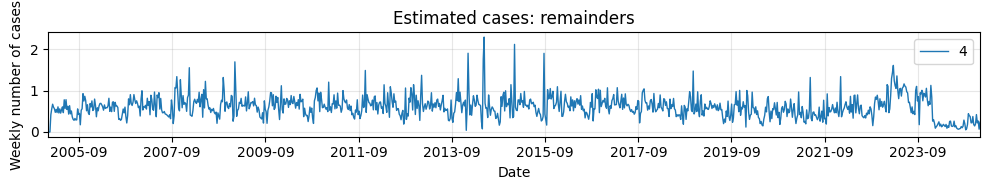

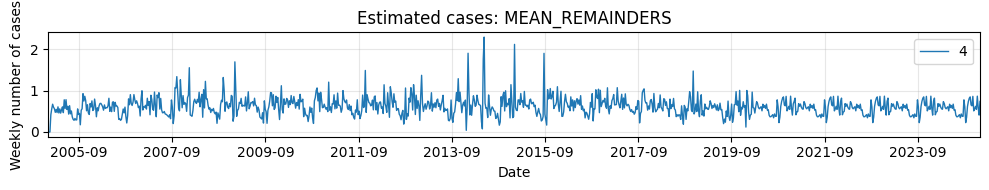

In [54]:
plotting.plot_model_results_age_range_in_range(state.REMAINDERS, 0, 0, "remainders")
plotting.plot_model_results_age_range_in_range(state.MEAN_REMAINDERS, 0, 0, "MEAN_REMAINDERS")
plotting.plot_model_results_age_range_in_range(state.REMAINDERS, 1, 1, "remainders")
plotting.plot_model_results_age_range_in_range(state.MEAN_REMAINDERS, 1, 1, "MEAN_REMAINDERS")
plotting.plot_model_results_age_range_in_range(state.REMAINDERS, 2, 2, "remainders")
plotting.plot_model_results_age_range_in_range(state.MEAN_REMAINDERS, 2, 2, "MEAN_REMAINDERS")
plotting.plot_model_results_age_range_in_range(state.REMAINDERS, 3, 3, "remainders")
plotting.plot_model_results_age_range_in_range(state.MEAN_REMAINDERS, 3, 3, "MEAN_REMAINDERS")
plotting.plot_model_results_age_range_in_range(state.REMAINDERS, 4, 4, "remainders")
plotting.plot_model_results_age_range_in_range(state.MEAN_REMAINDERS, 4, 4, "MEAN_REMAINDERS")

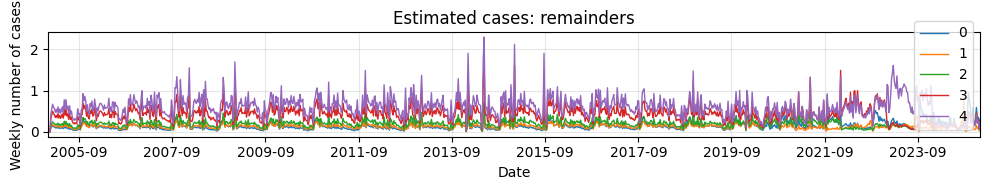

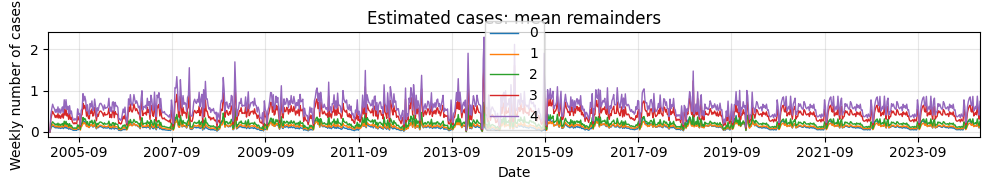

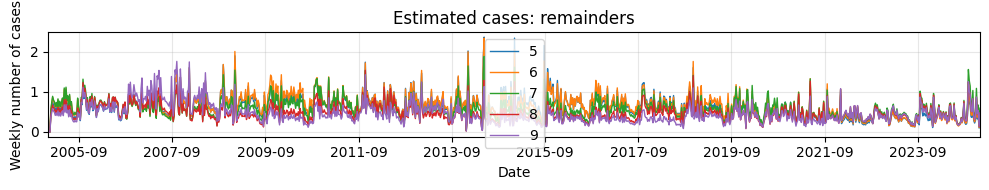

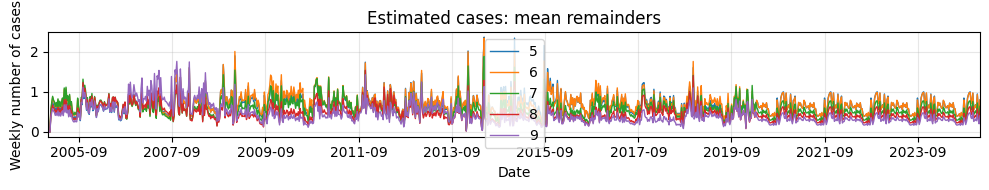

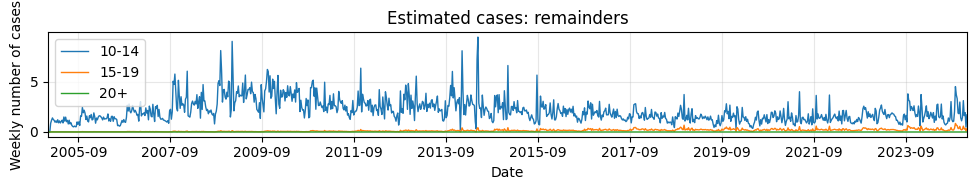

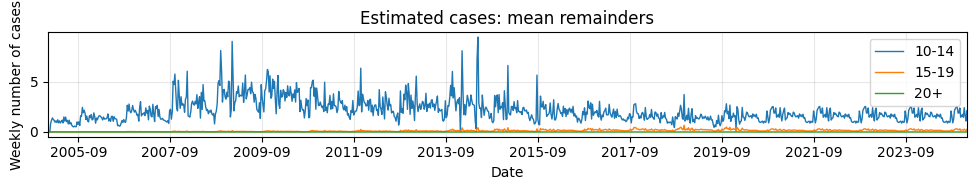

In [55]:
plotting.plot_model_results_age_range_in_range(state.REMAINDERS, 0, 4, "remainders")
plotting.plot_model_results_age_range_in_range(state.MEAN_REMAINDERS, 0, 4, "mean remainders")
plotting.plot_model_results_age_range_in_range(state.REMAINDERS, 5, 9, "remainders")
plotting.plot_model_results_age_range_in_range(state.MEAN_REMAINDERS, 5, 9, "mean remainders")
plotting.plot_model_results_age_range_in_range(state.REMAINDERS, 10, 12, "remainders")
plotting.plot_model_results_age_range_in_range(state.MEAN_REMAINDERS, 10, 12, "mean remainders")

In [56]:
scenarioCalculator.calculate_no_covid_population()

## Change vaccination level

### vaccination level = 1

In [57]:
no_cov_vacc_level_1 = scenarioCalculator.calculate_number_of_cases_for_scenario(
    #Scenarios.BASELINE, 1, GlobalConfig.START_OF_VACCINATION, True)
    Scenarios.NO_COVID_BASELINE, 1, GlobalConfig.START_OF_VACCINATION, False)
ALL_SCENARIOS.append(no_cov_vacc_level_1)

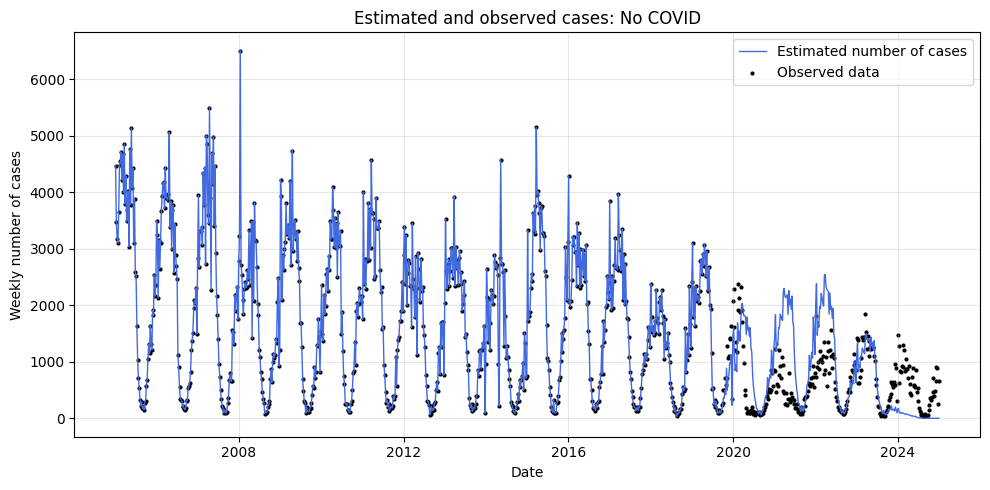

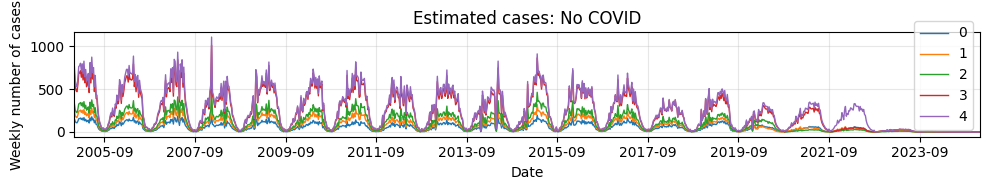

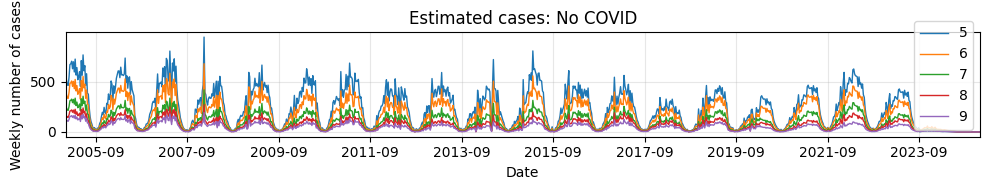

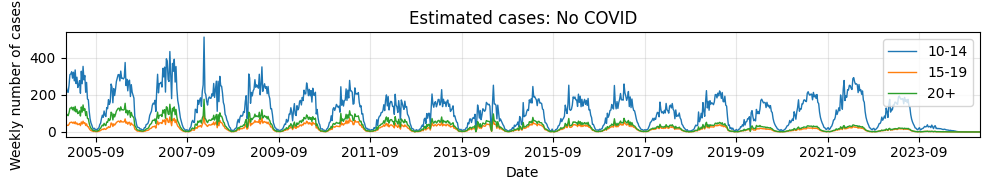

In [58]:
plotting.plot_model_actual_scat_comparison(no_cov_vacc_level_1)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_1.I, 0, 4, no_cov_vacc_level_1.name)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_1.I, 5, 9, no_cov_vacc_level_1.name)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_1.I, 10, 12, no_cov_vacc_level_1.name)

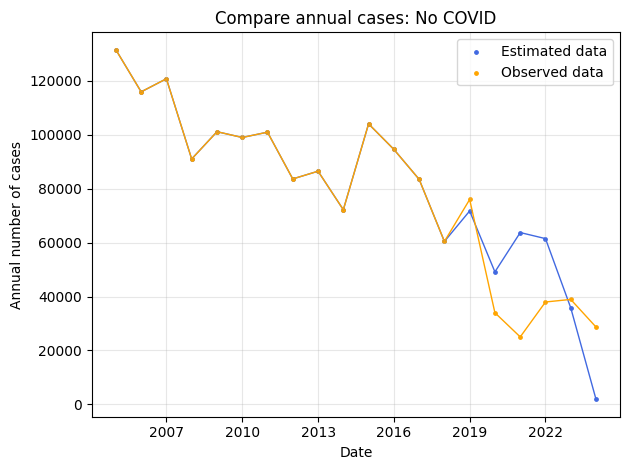

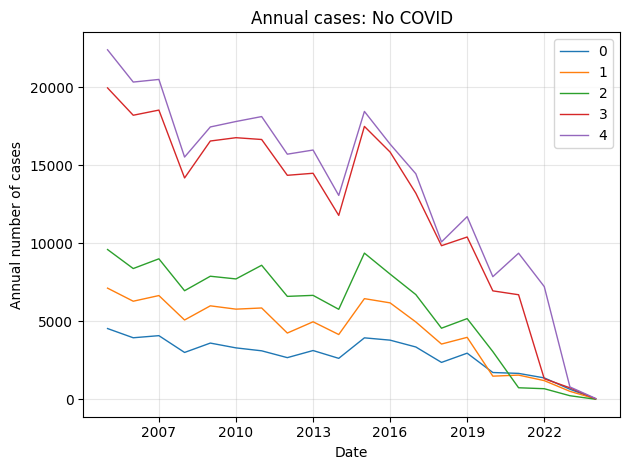

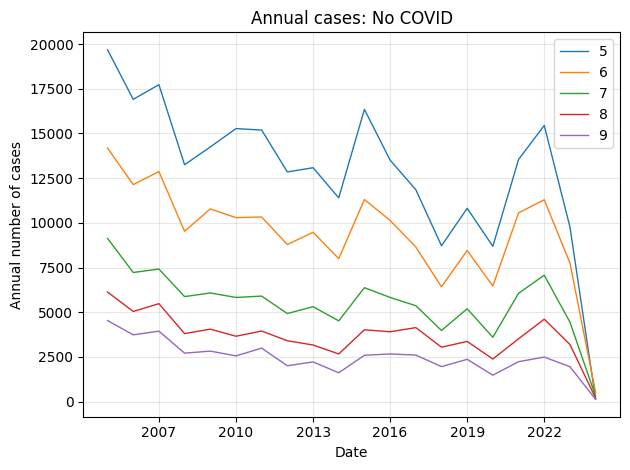

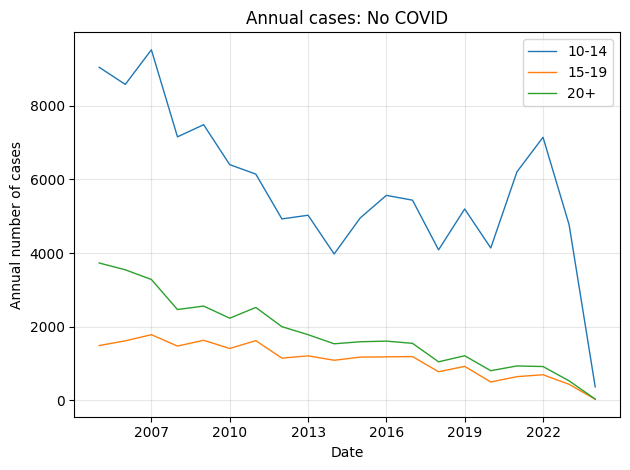

In [59]:
plotting.plot_compare_scenario_to_actual_case(no_cov_vacc_level_1.weekly_i_series, no_cov_vacc_level_1.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_1.I, 0, 4, no_cov_vacc_level_1.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_1.I, 5, 9, no_cov_vacc_level_1.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_1.I, 10, 12, no_cov_vacc_level_1.name)

### Vaccination level = 0.75

In [60]:
no_cov_vacc_level_75 = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_LEVEL_75, 0.75, GlobalConfig.START_OF_VACCINATION, False)
ALL_SCENARIOS.append(no_cov_vacc_level_75)

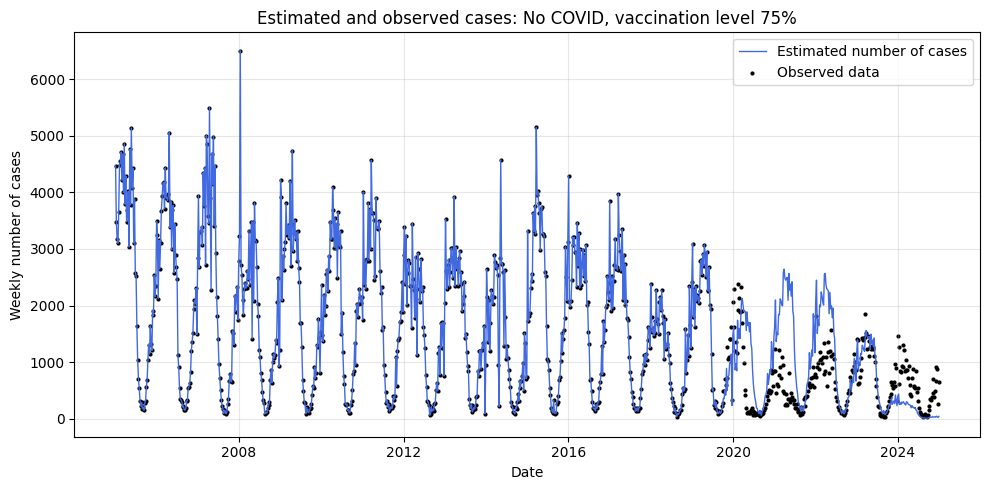

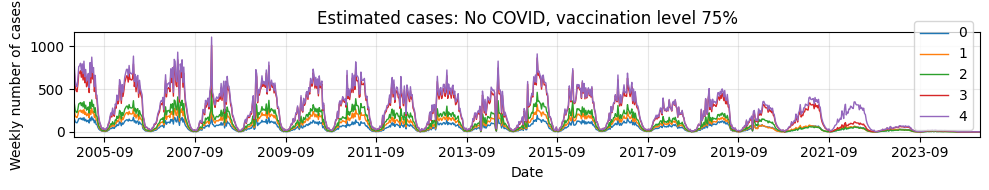

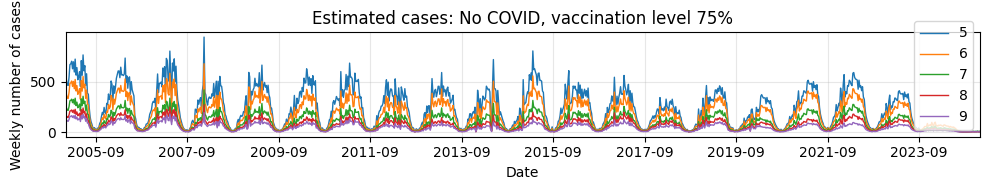

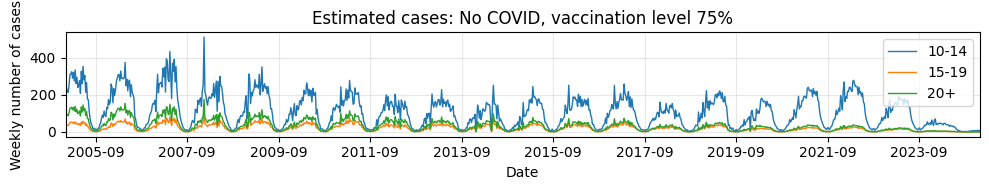

In [61]:
plotting.plot_model_actual_scat_comparison(no_cov_vacc_level_75)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_75.I, 0, 4, no_cov_vacc_level_75.name)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_75.I, 5, 9, no_cov_vacc_level_75.name)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_75.I, 10, 12, no_cov_vacc_level_75.name)

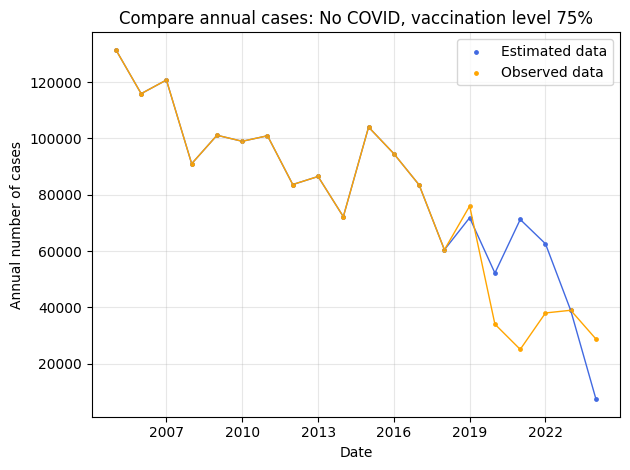

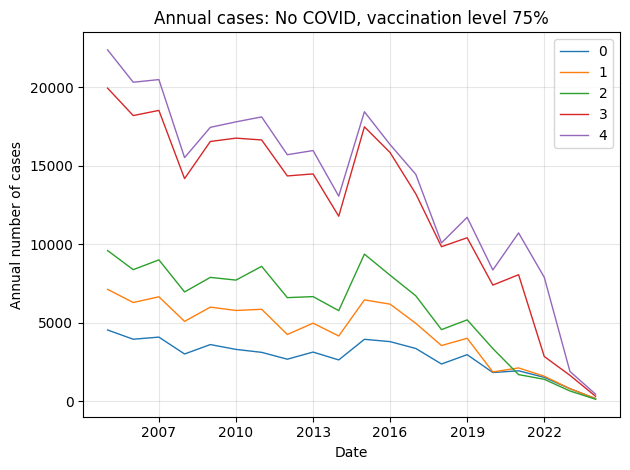

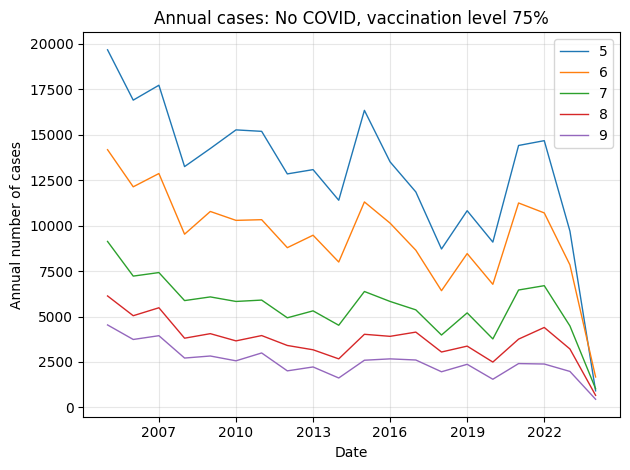

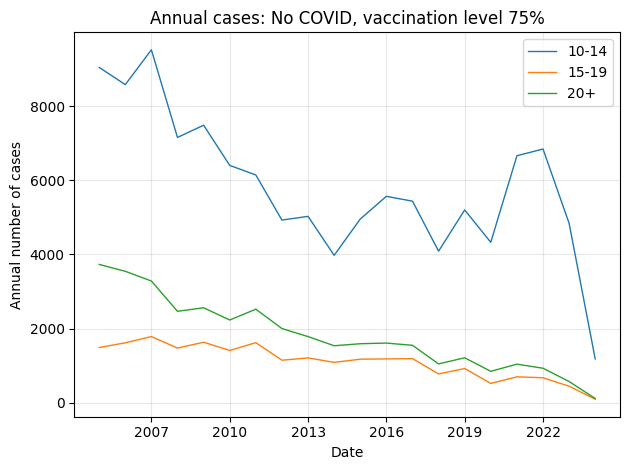

In [62]:
plotting.plot_compare_scenario_to_actual_case(no_cov_vacc_level_75.weekly_i_series, no_cov_vacc_level_75.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_75.I, 0, 4, no_cov_vacc_level_75.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_75.I, 5, 9, no_cov_vacc_level_75.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_75.I, 10, 12, no_cov_vacc_level_75.name)

### Vaccination level = 0.5

In [63]:
no_cov_vacc_level_50 = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_LEVEL_50, 0.5, GlobalConfig.START_OF_VACCINATION, False)
ALL_SCENARIOS.append(no_cov_vacc_level_50)

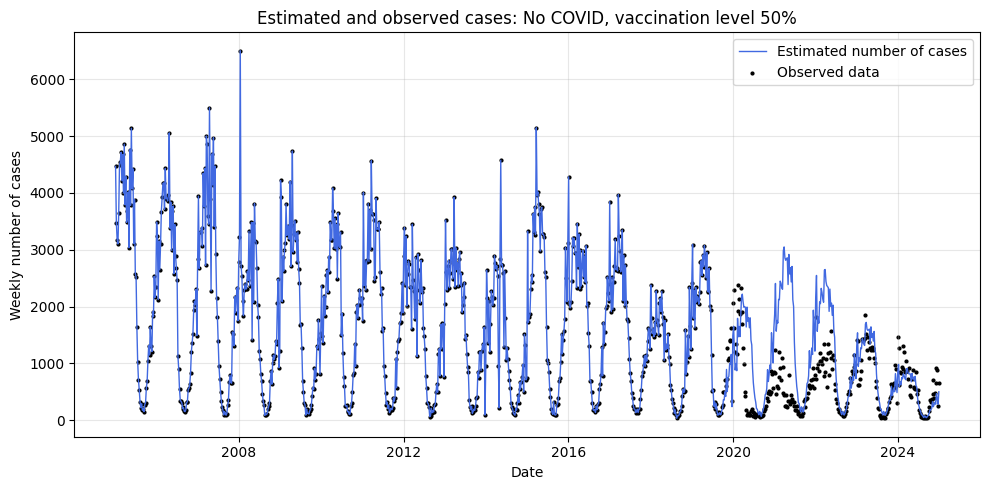

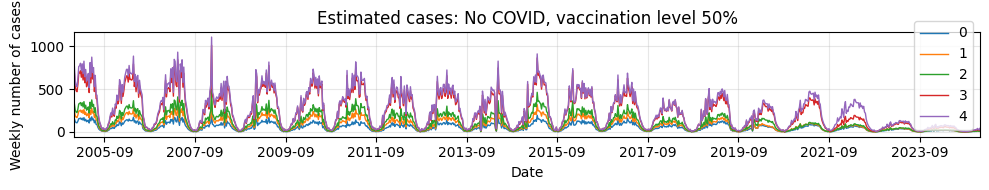

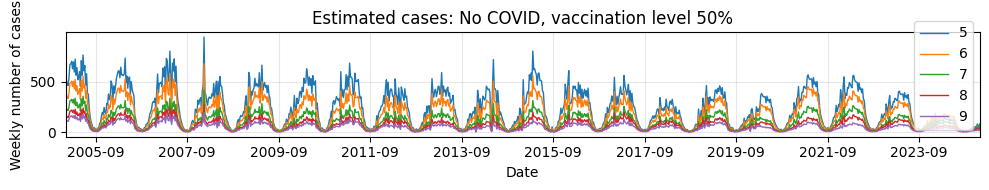

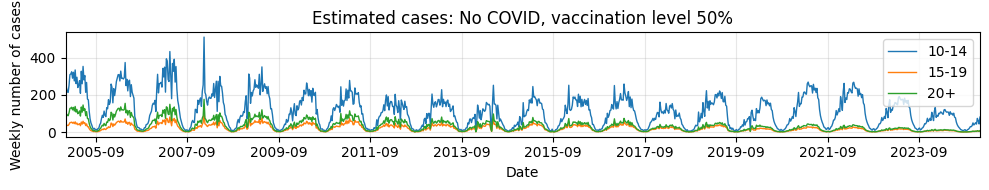

In [64]:
plotting.plot_model_actual_scat_comparison(no_cov_vacc_level_50)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_50.I, 0, 4, no_cov_vacc_level_50.name)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_50.I, 5, 9, no_cov_vacc_level_50.name)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_50.I, 10, 12, no_cov_vacc_level_50.name)

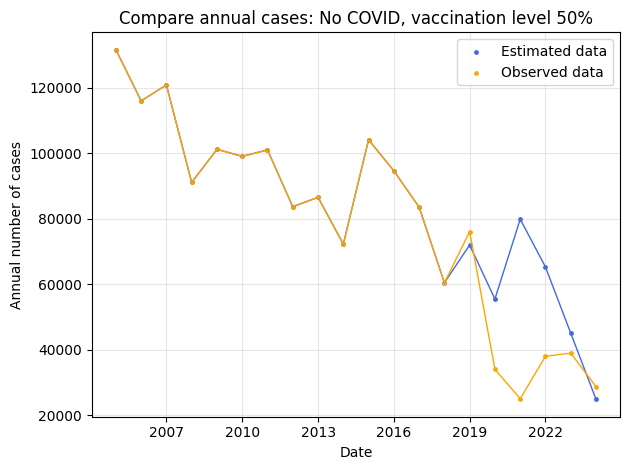

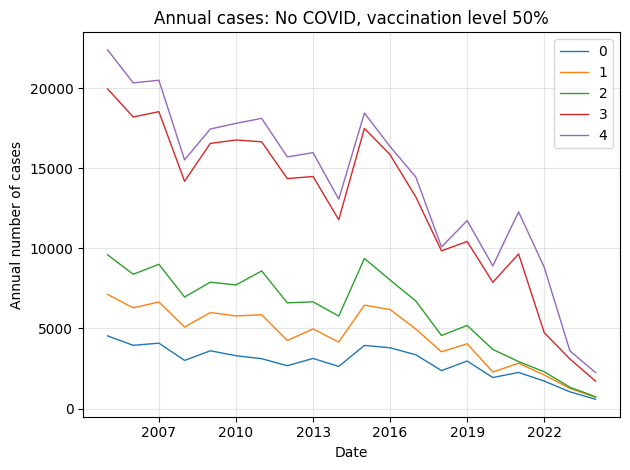

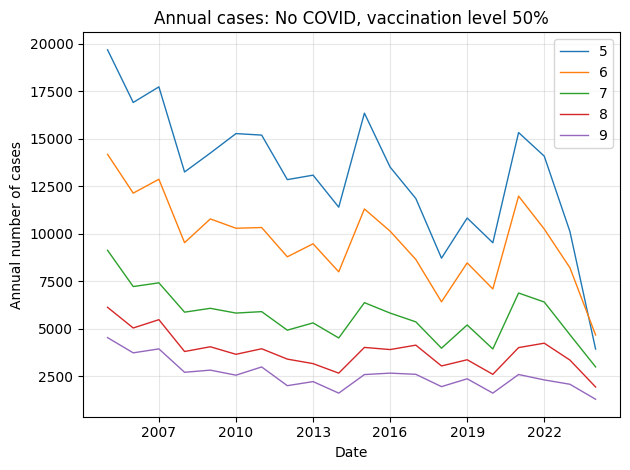

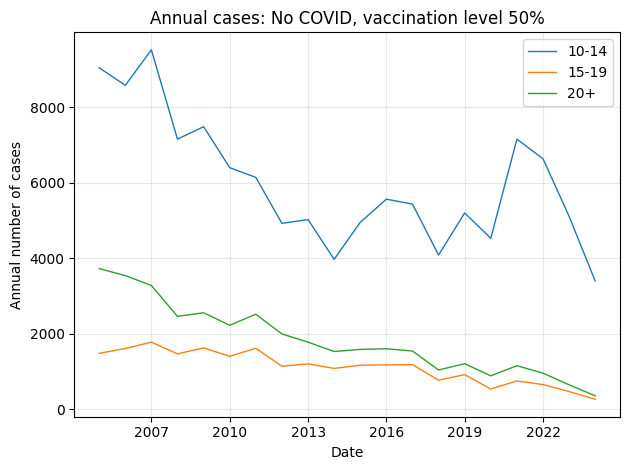

In [65]:
plotting.plot_compare_scenario_to_actual_case(no_cov_vacc_level_50.weekly_i_series, no_cov_vacc_level_50.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_50.I, 0, 4, no_cov_vacc_level_50.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_50.I, 5, 9, no_cov_vacc_level_50.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_50.I, 10, 12, no_cov_vacc_level_50.name)

### Vaccination level = 0.25

In [66]:
no_cov_vacc_level_25 = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_LEVEL_25, 0.25, GlobalConfig.START_OF_VACCINATION, False)
ALL_SCENARIOS.append(no_cov_vacc_level_25)

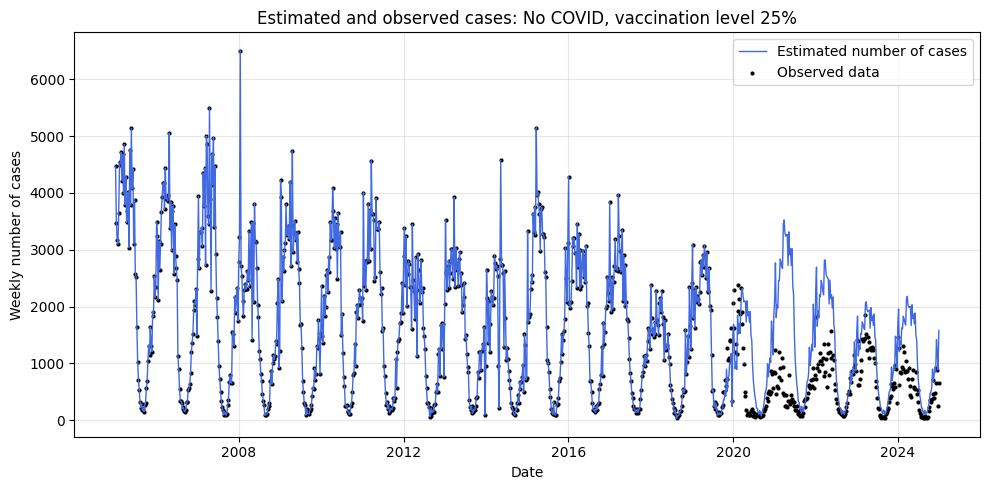

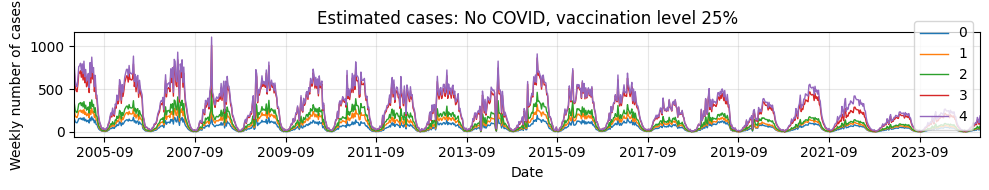

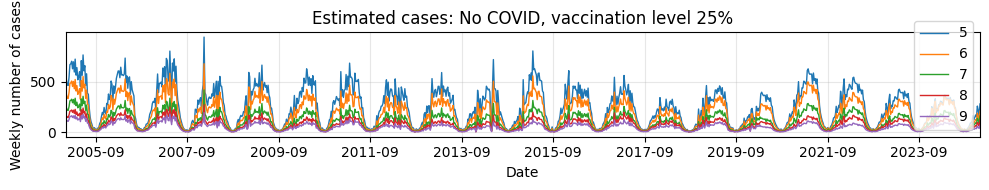

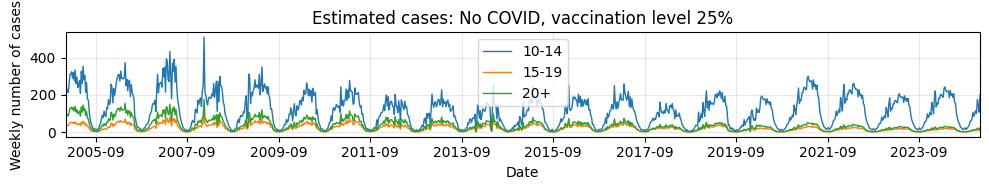

In [67]:
plotting.plot_model_actual_scat_comparison(no_cov_vacc_level_25)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_25.I, 0, 4, no_cov_vacc_level_25.name)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_25.I, 5, 9, no_cov_vacc_level_25.name)
plotting.plot_model_results_age_range_in_range(no_cov_vacc_level_25.I, 10, 12, no_cov_vacc_level_25.name)

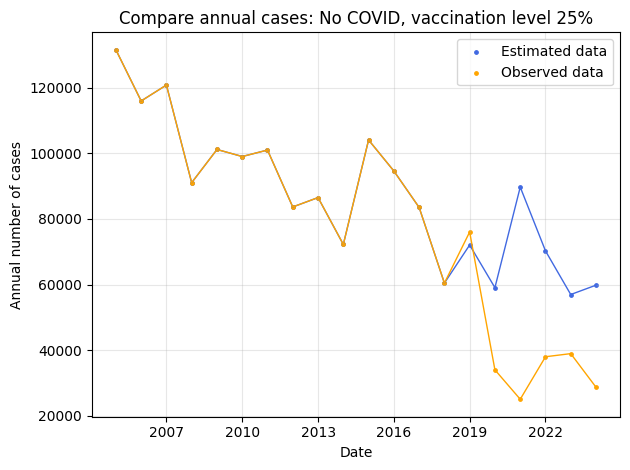

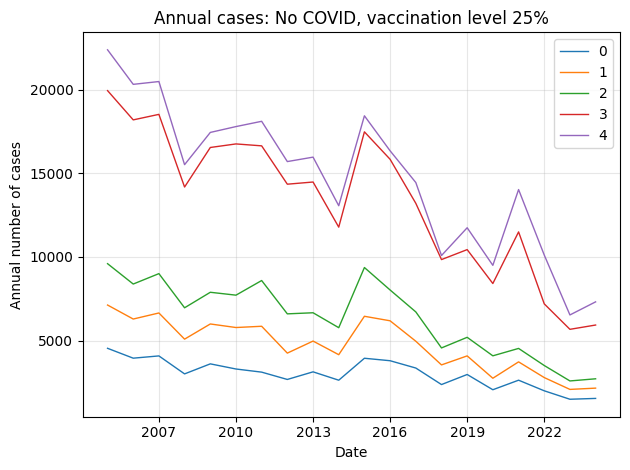

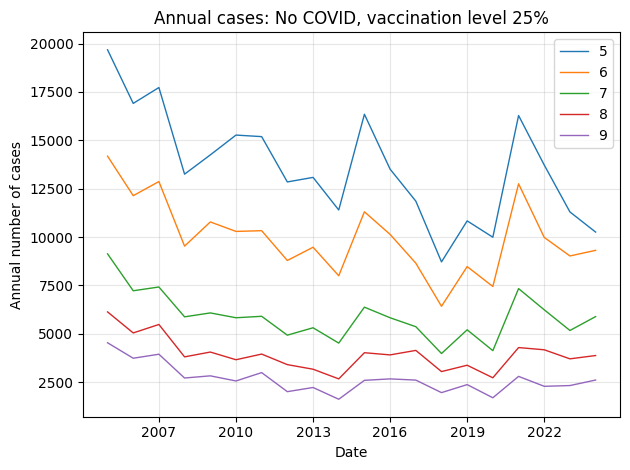

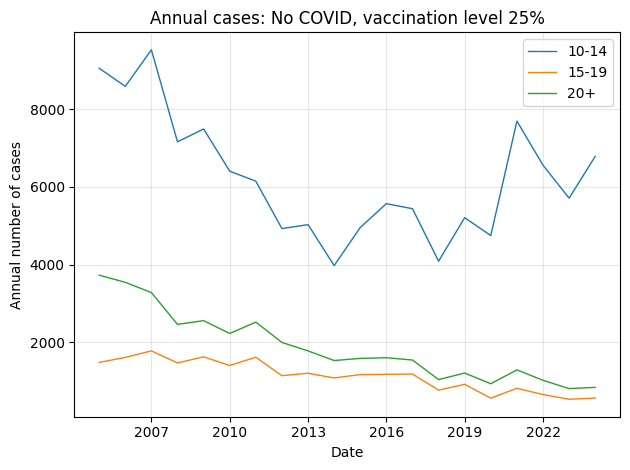

In [68]:
plotting.plot_compare_scenario_to_actual_case(no_cov_vacc_level_25.weekly_i_series, no_cov_vacc_level_25.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_25.I, 0, 4, no_cov_vacc_level_25.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_25.I, 5, 9, no_cov_vacc_level_25.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_vacc_level_25.I, 10, 12, no_cov_vacc_level_25.name)

### Vaccination level = 0

In [69]:
no_cov_no_vacc = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_NO_VACC, 0, GlobalConfig.START_OF_VACCINATION, False)
ALL_SCENARIOS.append(no_cov_no_vacc)

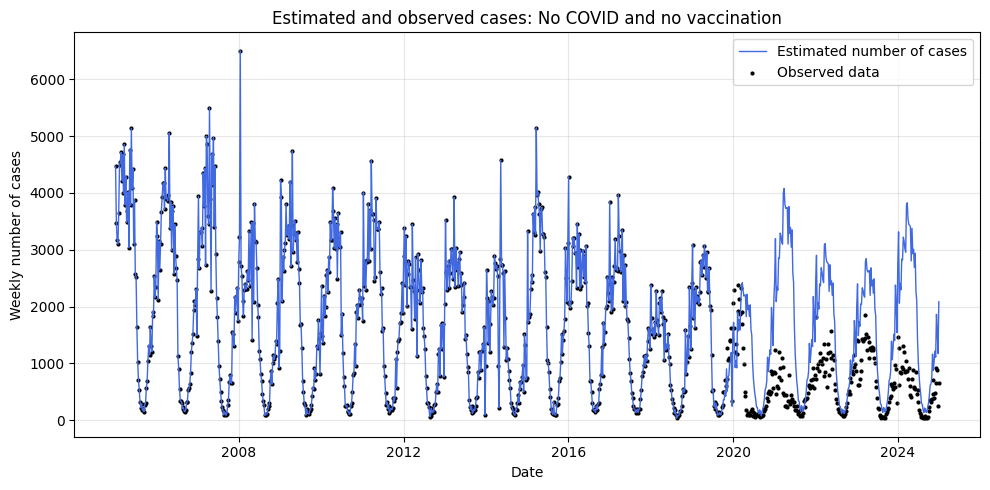

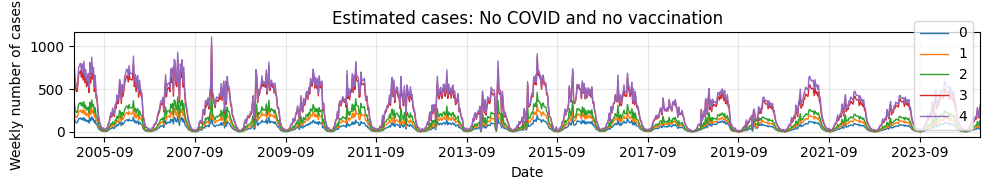

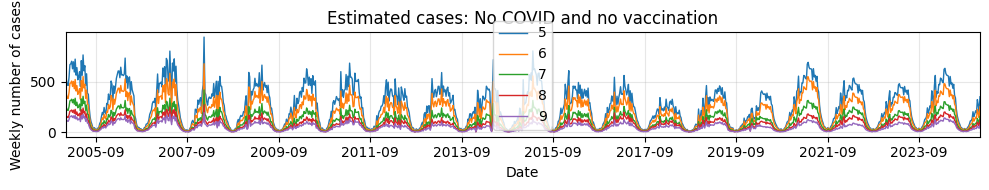

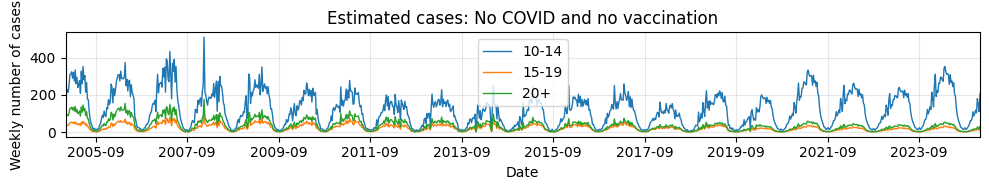

In [70]:
plotting.plot_model_actual_scat_comparison(no_cov_no_vacc)
plotting.plot_model_results_age_range_in_range(no_cov_no_vacc.I, 0, 4, no_cov_no_vacc.name)
plotting.plot_model_results_age_range_in_range(no_cov_no_vacc.I, 5, 9, no_cov_no_vacc.name)
plotting.plot_model_results_age_range_in_range(no_cov_no_vacc.I, 10, 12, no_cov_no_vacc.name)

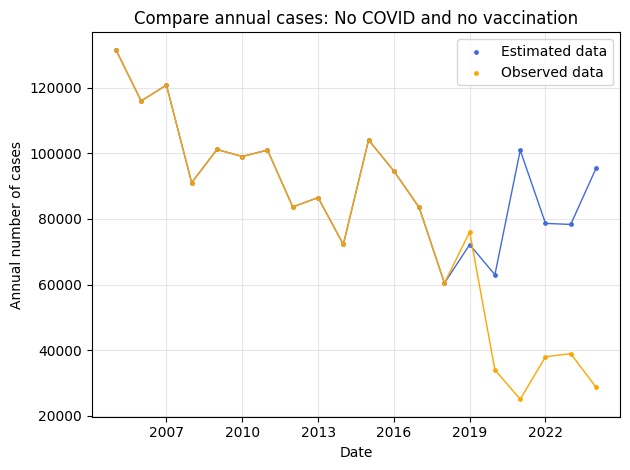

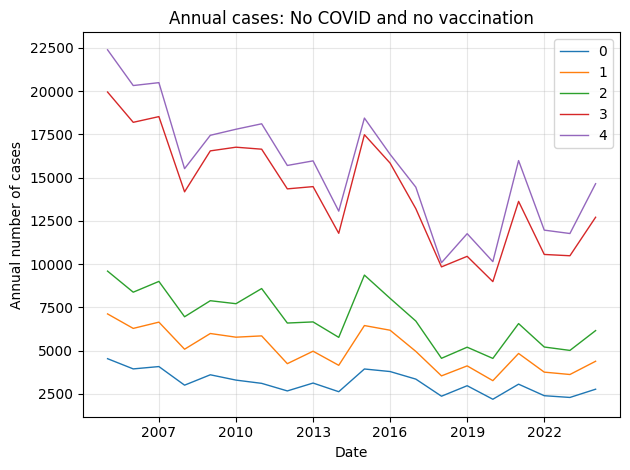

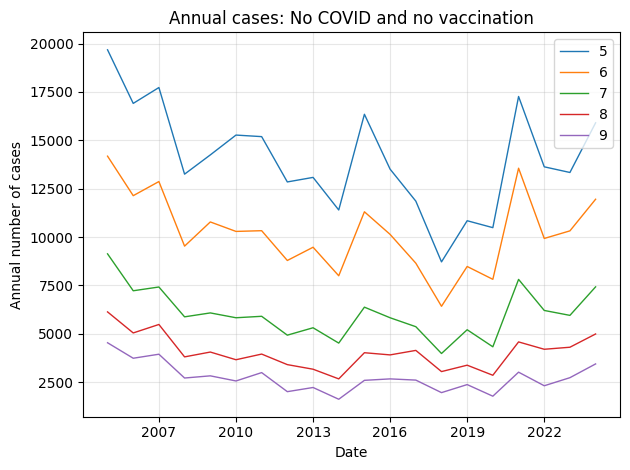

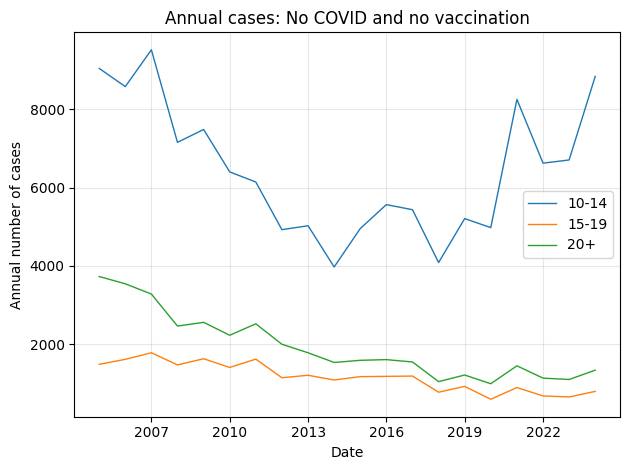

In [71]:
plotting.plot_compare_scenario_to_actual_case(no_cov_no_vacc.weekly_i_series, no_cov_no_vacc.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_no_vacc.I, 0, 4, no_cov_no_vacc.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_no_vacc.I, 5, 9, no_cov_no_vacc.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_no_vacc.I, 10, 12, no_cov_no_vacc.name)

## Starting vaccination earlier

### Start vaccination 1 year earlier (2018.09.01)

In [72]:
no_cov_1_year_minus = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_1_YEAR_MINUS, 1, GlobalConfig.START_OF_VACCINATION + pd.DateOffset(years=-1), False)
ALL_SCENARIOS.append(no_cov_1_year_minus)

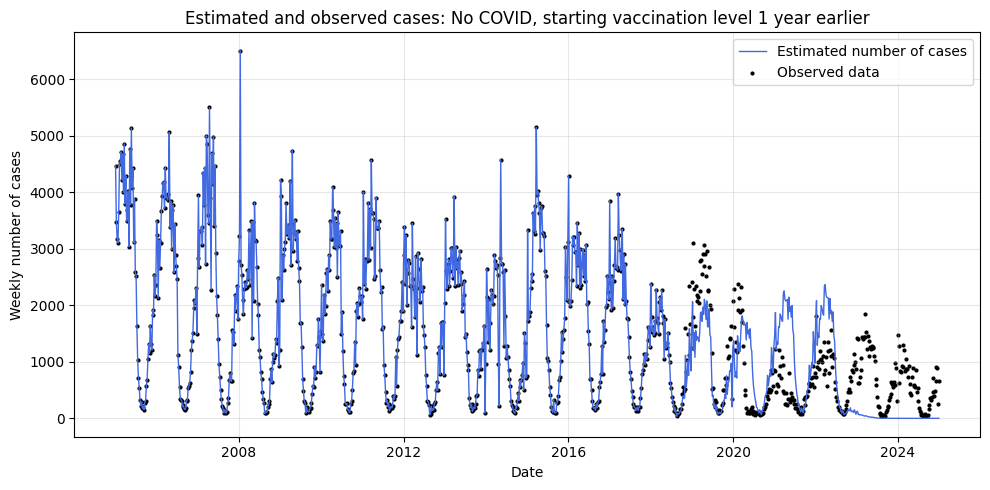

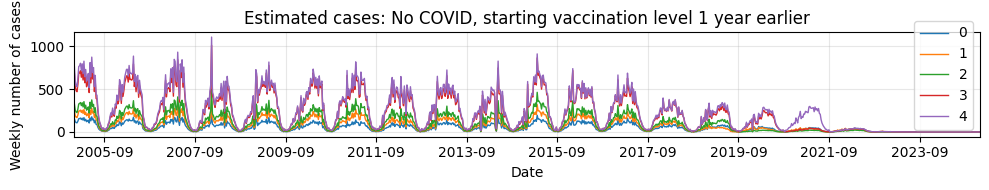

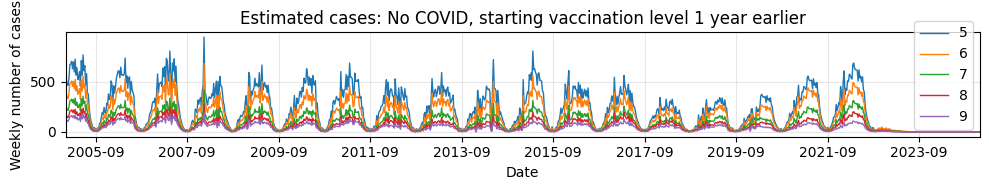

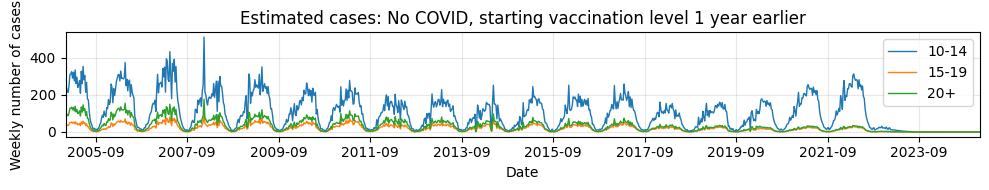

In [73]:
plotting.plot_model_actual_scat_comparison(no_cov_1_year_minus)
plotting.plot_model_results_age_range_in_range(no_cov_1_year_minus.I, 0, 4, no_cov_1_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_1_year_minus.I, 5, 9, no_cov_1_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_1_year_minus.I, 10, 12, no_cov_1_year_minus.name)

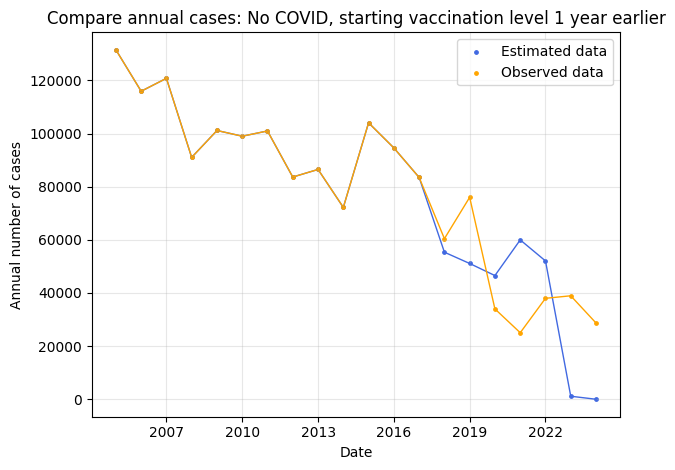

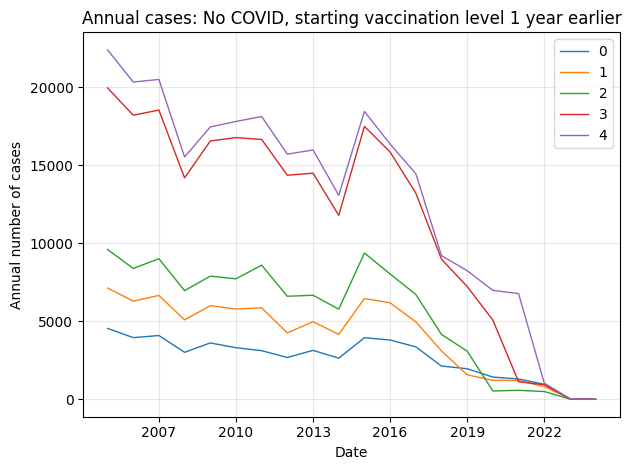

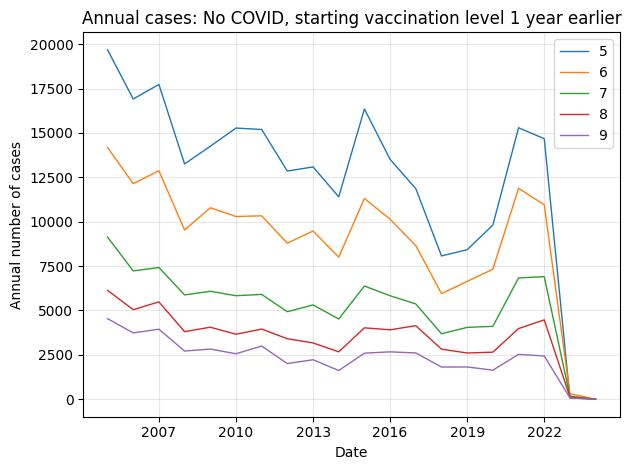

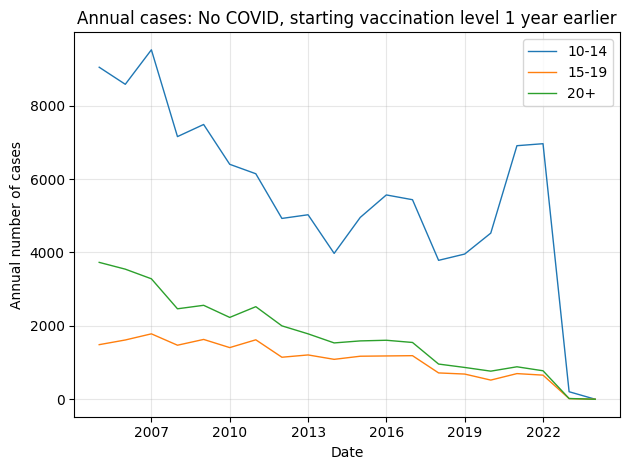

In [74]:
plotting.plot_compare_scenario_to_actual_case(no_cov_1_year_minus.weekly_i_series, no_cov_1_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_1_year_minus.I, 0, 4, no_cov_1_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_1_year_minus.I, 5, 9, no_cov_1_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_1_year_minus.I, 10, 12, no_cov_1_year_minus.name)

### Start vaccination 2 years earlier (2017.09.01)

In [75]:
no_cov_2_year_minus = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_2_YEAR_MINUS, 1, GlobalConfig.START_OF_VACCINATION + pd.DateOffset(years=-2), False)
ALL_SCENARIOS.append(no_cov_2_year_minus)

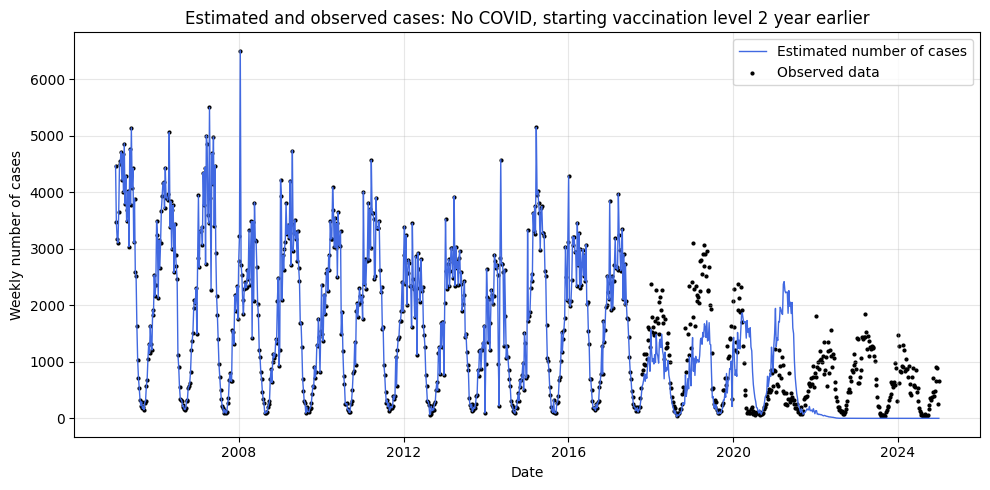

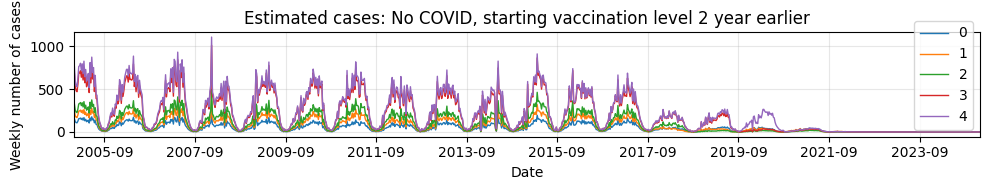

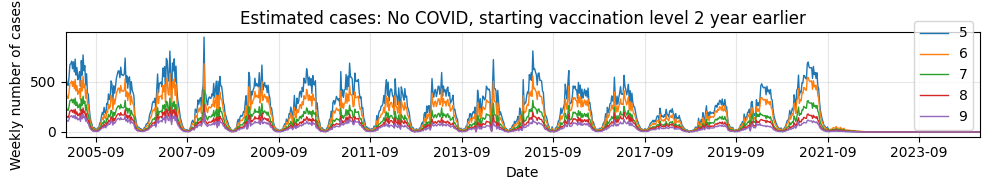

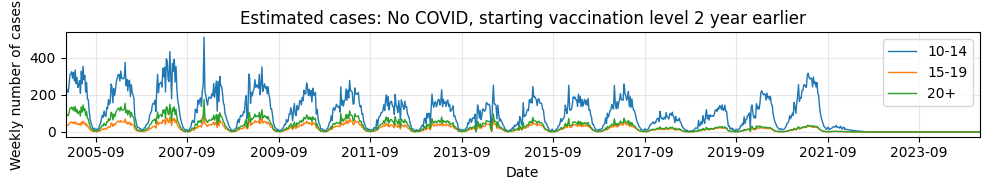

In [76]:
plotting.plot_model_actual_scat_comparison(no_cov_2_year_minus)
plotting.plot_model_results_age_range_in_range(no_cov_2_year_minus.I, 0, 4, no_cov_2_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_2_year_minus.I, 5, 9, no_cov_2_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_2_year_minus.I, 10, 12, no_cov_2_year_minus.name)

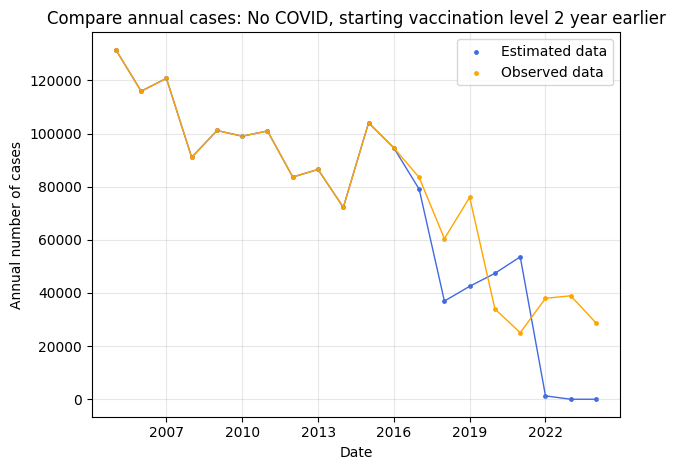

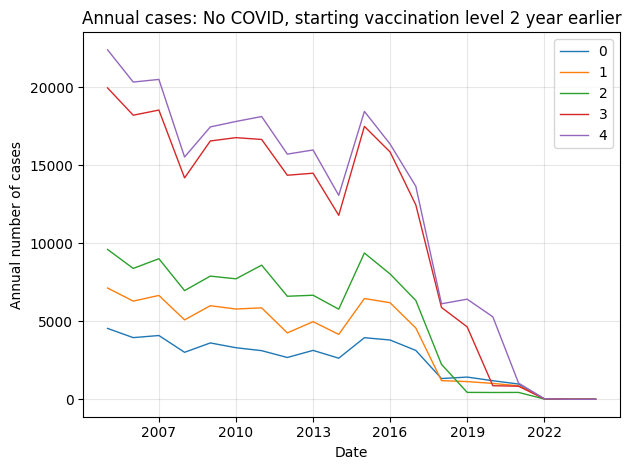

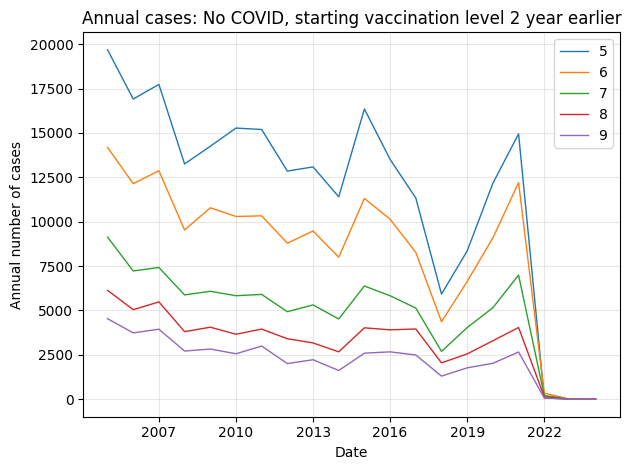

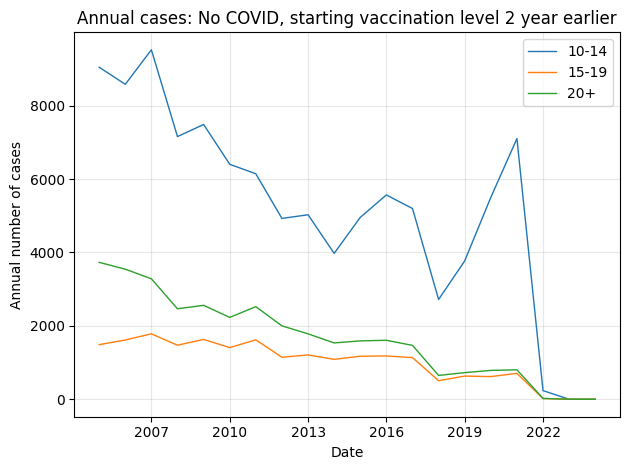

In [77]:
plotting.plot_compare_scenario_to_actual_case(no_cov_2_year_minus.weekly_i_series, no_cov_2_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_2_year_minus.I, 0, 4, no_cov_2_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_2_year_minus.I, 5, 9, no_cov_2_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_2_year_minus.I, 10, 12, no_cov_2_year_minus.name)

### Start vaccination 3 years earlier (2016.09.01)

In [78]:
no_cov_3_year_minus = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_3_YEAR_MINUS, 1, GlobalConfig.START_OF_VACCINATION + pd.DateOffset(years=-3), False)
ALL_SCENARIOS.append(no_cov_3_year_minus)

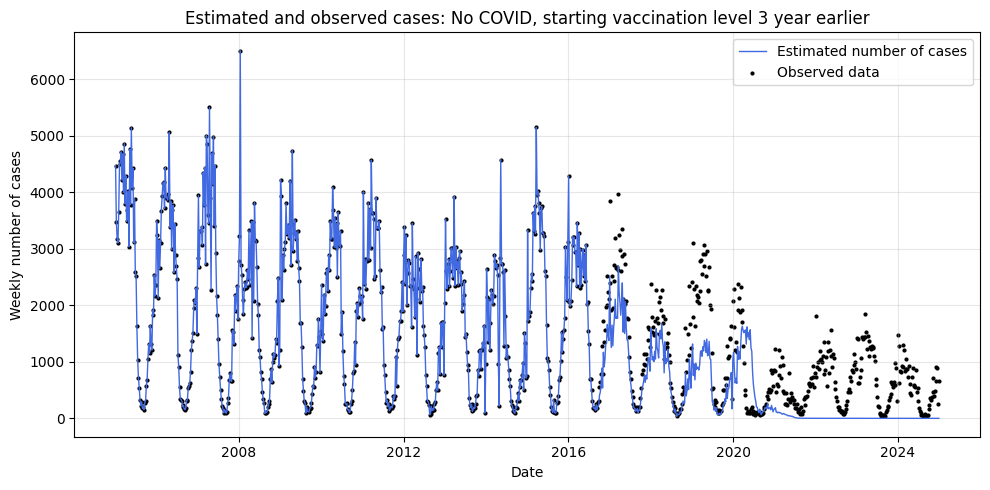

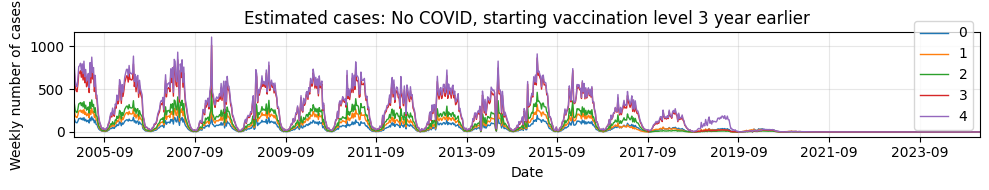

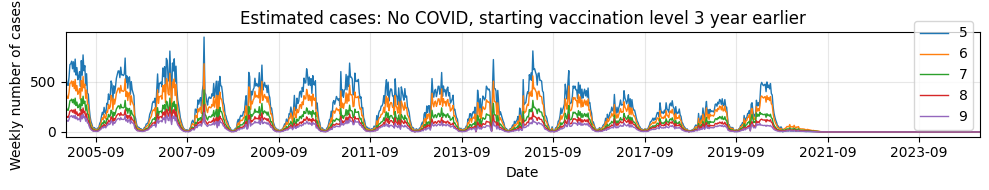

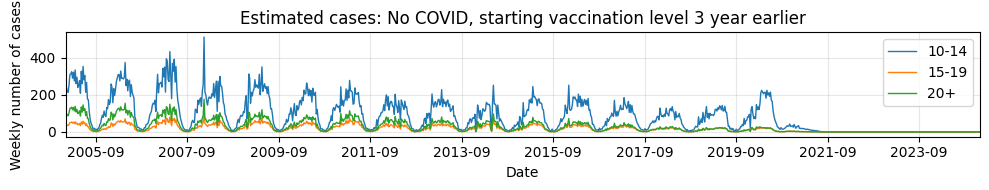

In [79]:
plotting.plot_model_actual_scat_comparison(no_cov_3_year_minus)
plotting.plot_model_results_age_range_in_range(no_cov_3_year_minus.I, 0, 4, no_cov_3_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_3_year_minus.I, 5, 9, no_cov_3_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_3_year_minus.I, 10, 12, no_cov_3_year_minus.name)

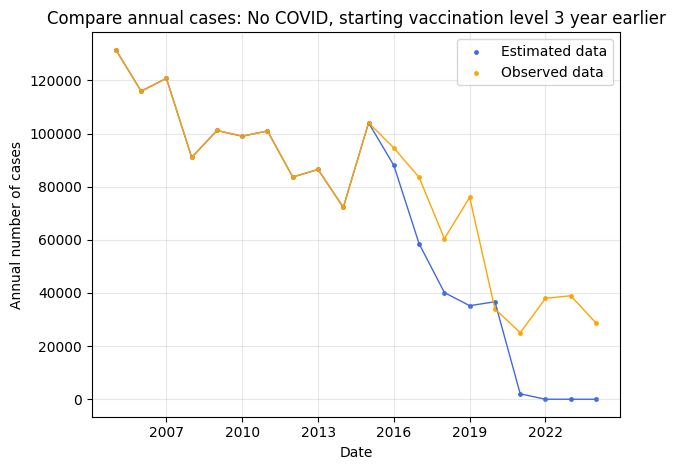

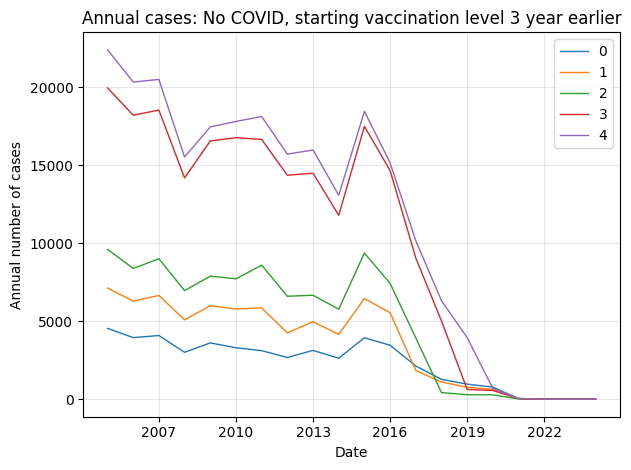

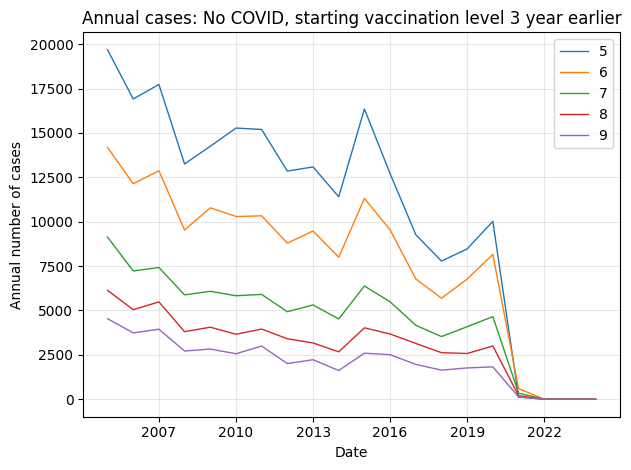

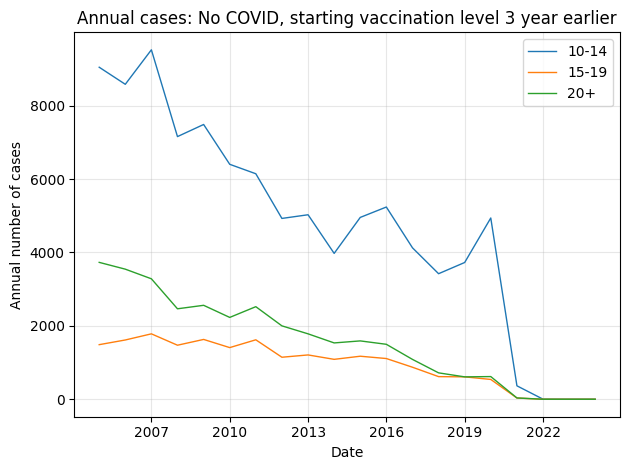

In [80]:
plotting.plot_compare_scenario_to_actual_case(no_cov_3_year_minus.weekly_i_series, no_cov_3_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_3_year_minus.I, 0, 4, no_cov_3_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_3_year_minus.I, 5, 9, no_cov_3_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_3_year_minus.I, 10, 12, no_cov_3_year_minus.name)

### Start vaccination 5 years earlier (2014.09.01)

In [81]:
no_cov_5_year_minus = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_5_YEAR_MINUS, 1, GlobalConfig.START_OF_VACCINATION + pd.DateOffset(years=-5), False)
ALL_SCENARIOS.append(no_cov_5_year_minus)

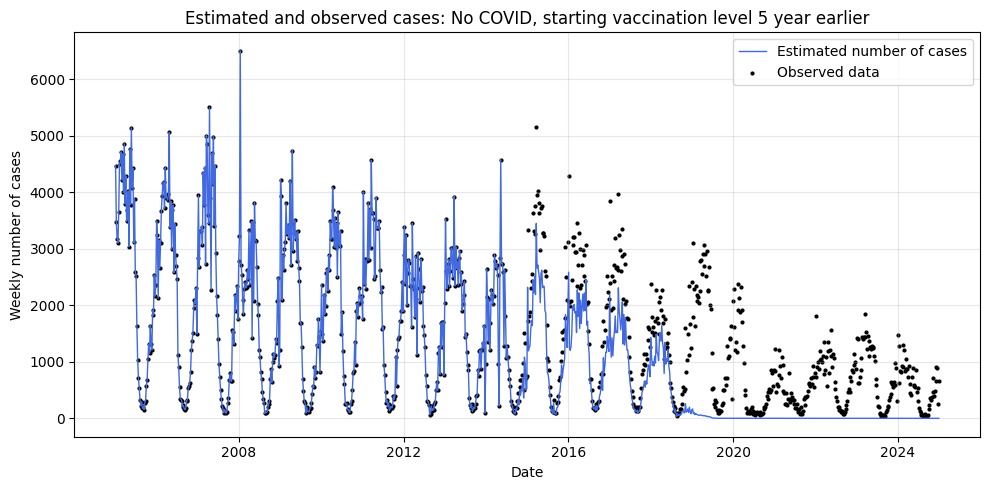

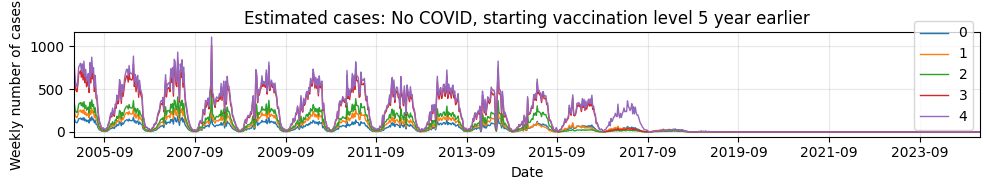

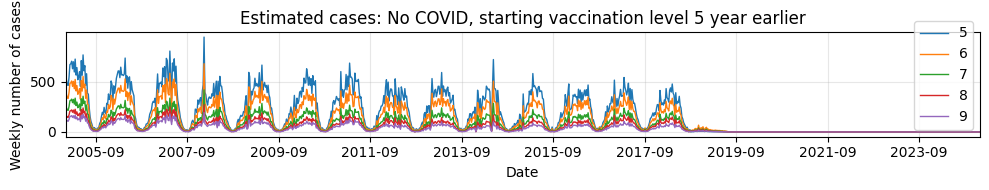

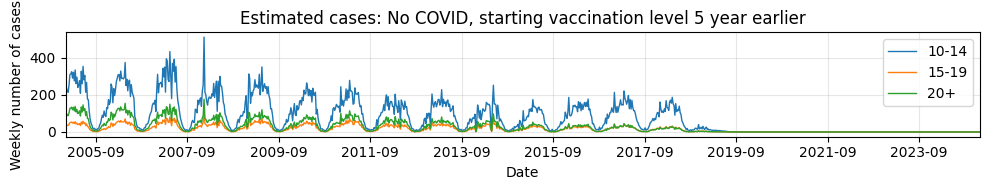

In [82]:
plotting.plot_model_actual_scat_comparison(no_cov_5_year_minus)
plotting.plot_model_results_age_range_in_range(no_cov_5_year_minus.I, 0, 4, no_cov_5_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_5_year_minus.I, 5, 9, no_cov_5_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_5_year_minus.I, 10, 12, no_cov_5_year_minus.name)

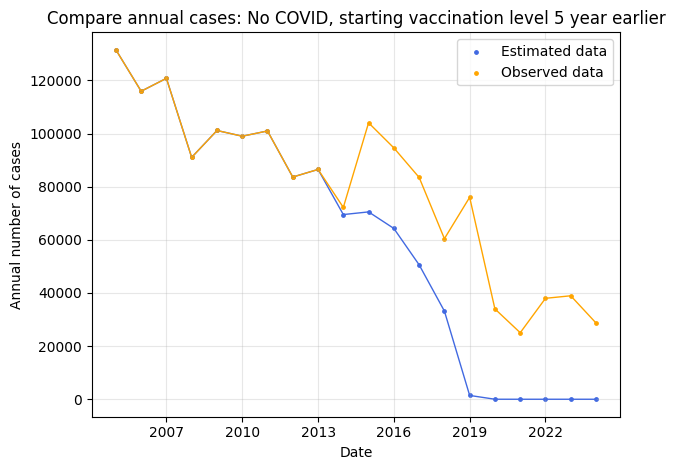

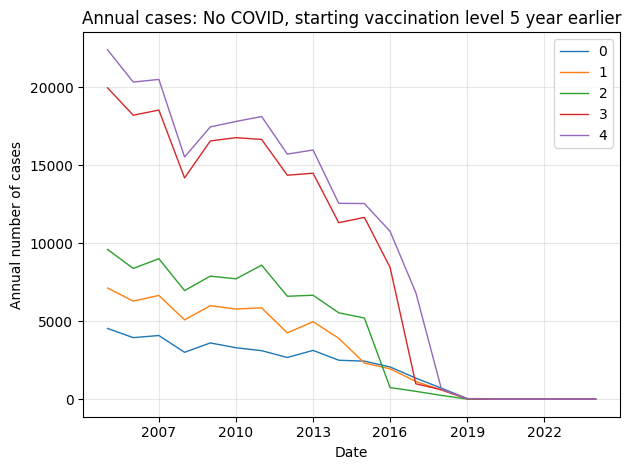

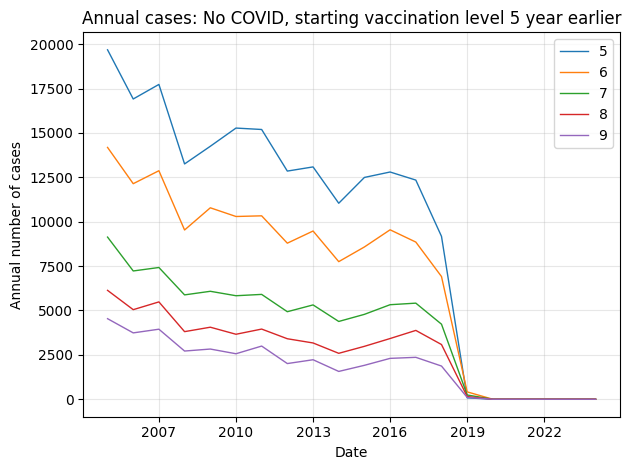

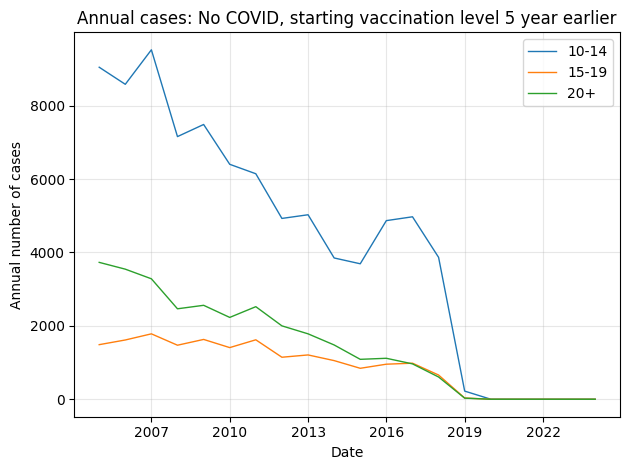

In [83]:
plotting.plot_compare_scenario_to_actual_case(no_cov_5_year_minus.weekly_i_series, no_cov_5_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_5_year_minus.I, 0, 4, no_cov_5_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_5_year_minus.I, 5, 9, no_cov_5_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_5_year_minus.I, 10, 12, no_cov_5_year_minus.name)

### Start vaccination 8 years earlier (2011.09.01)

In [84]:
no_cov_8_year_minus = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_8_YEAR_MINUS, 1, GlobalConfig.START_OF_VACCINATION + pd.DateOffset(years=-8), False)
ALL_SCENARIOS.append(no_cov_8_year_minus)

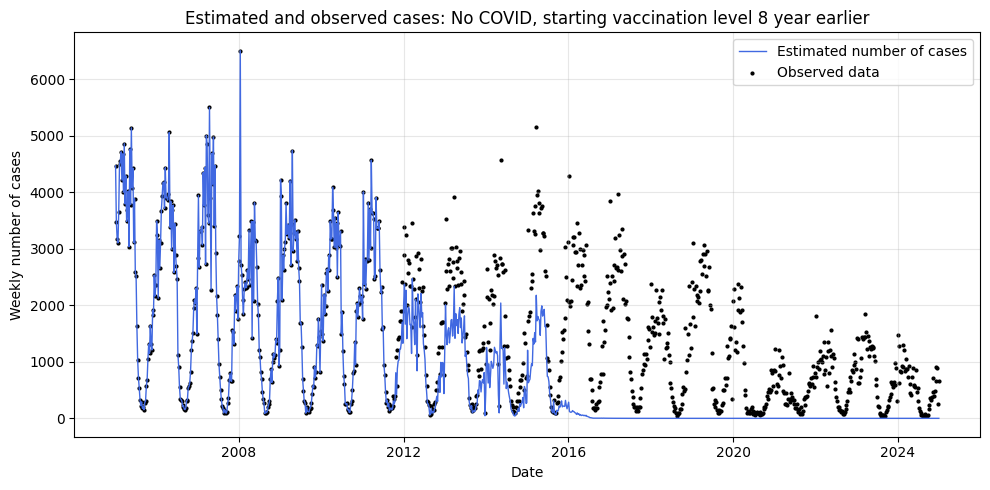

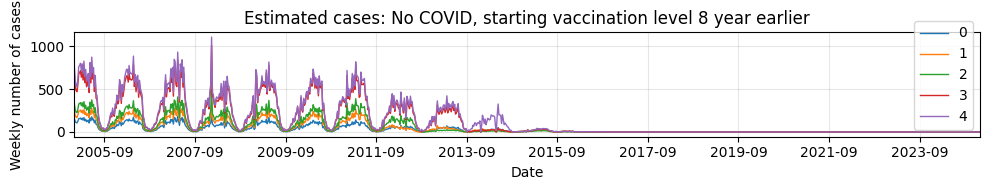

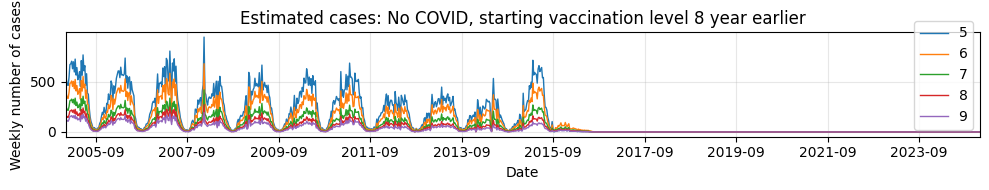

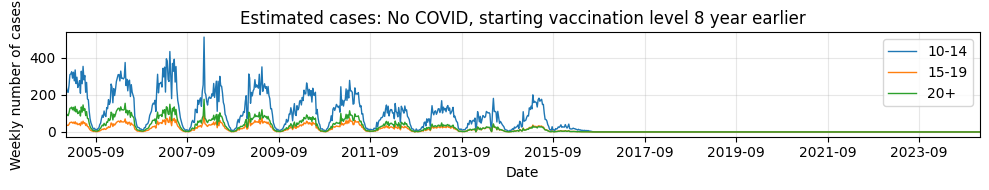

In [85]:
plotting.plot_model_actual_scat_comparison(no_cov_8_year_minus)
plotting.plot_model_results_age_range_in_range(no_cov_8_year_minus.I, 0, 4, no_cov_8_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_8_year_minus.I, 5, 9, no_cov_8_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_8_year_minus.I, 10, 12, no_cov_8_year_minus.name)

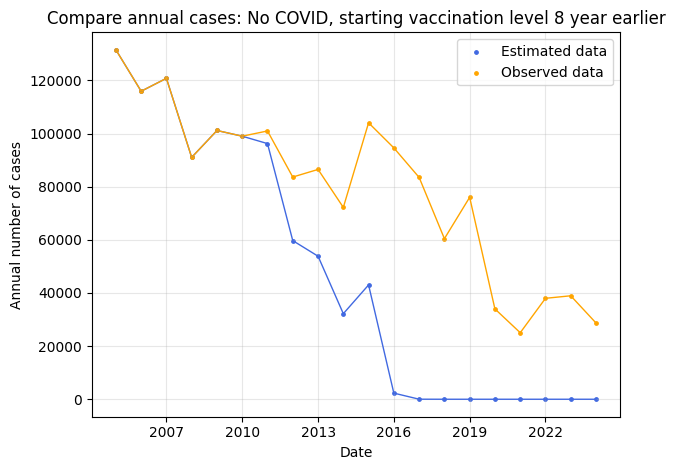

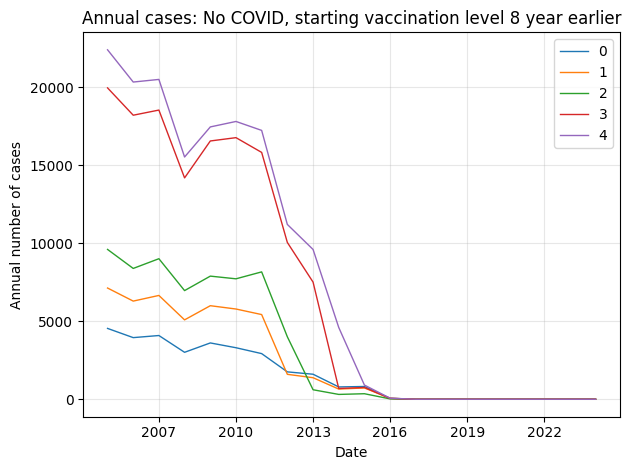

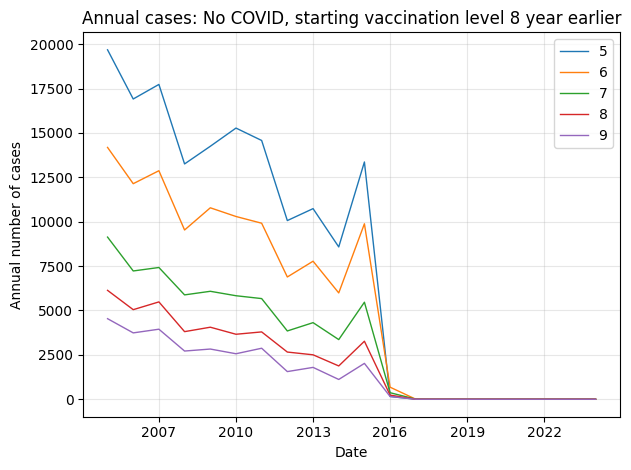

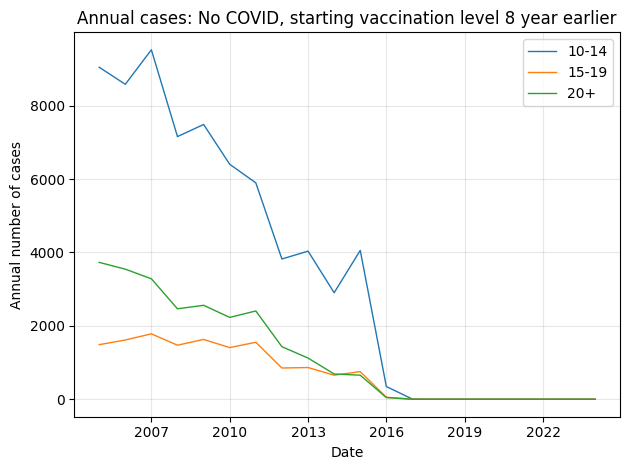

In [86]:
plotting.plot_compare_scenario_to_actual_case(no_cov_8_year_minus.weekly_i_series, no_cov_8_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_8_year_minus.I, 0, 4, no_cov_8_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_8_year_minus.I, 5, 9, no_cov_8_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_8_year_minus.I, 10, 12, no_cov_8_year_minus.name)

### Start vaccination 13 years earlier (2006.09.01)

In [87]:
no_cov_13_year_minus = scenarioCalculator.calculate_number_of_cases_for_scenario(
    Scenarios.NO_COVID_VACC_13_YEAR_MINUS, 1, GlobalConfig.START_OF_VACCINATION + pd.DateOffset(years=-13), False)
ALL_SCENARIOS.append(no_cov_13_year_minus)

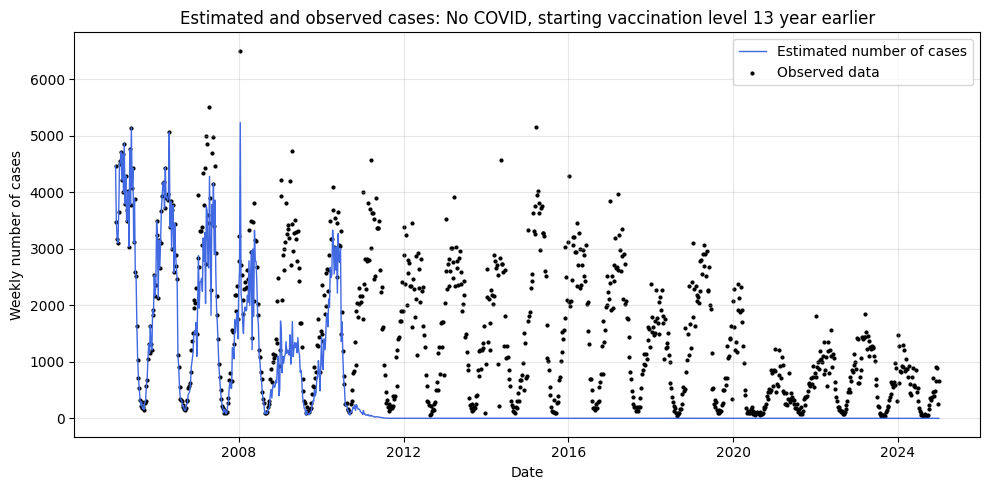

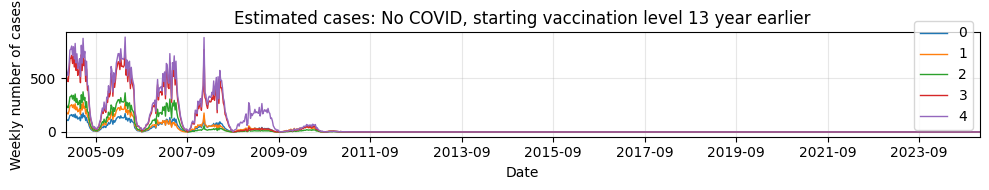

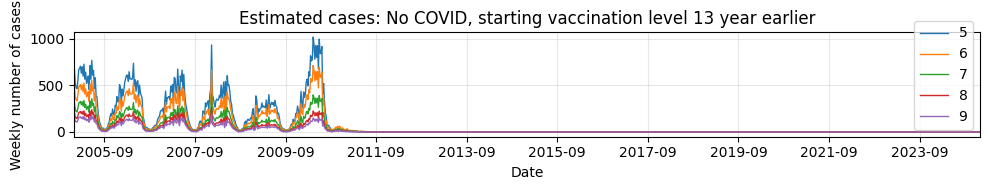

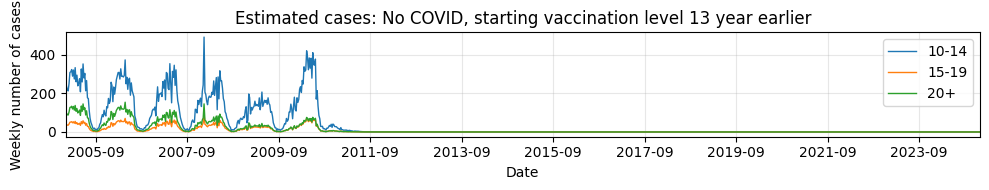

In [88]:
plotting.plot_model_actual_scat_comparison(no_cov_13_year_minus)
plotting.plot_model_results_age_range_in_range(no_cov_13_year_minus.I, 0, 4, no_cov_13_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_13_year_minus.I, 5, 9, no_cov_13_year_minus.name)
plotting.plot_model_results_age_range_in_range(no_cov_13_year_minus.I, 10, 12, no_cov_13_year_minus.name)

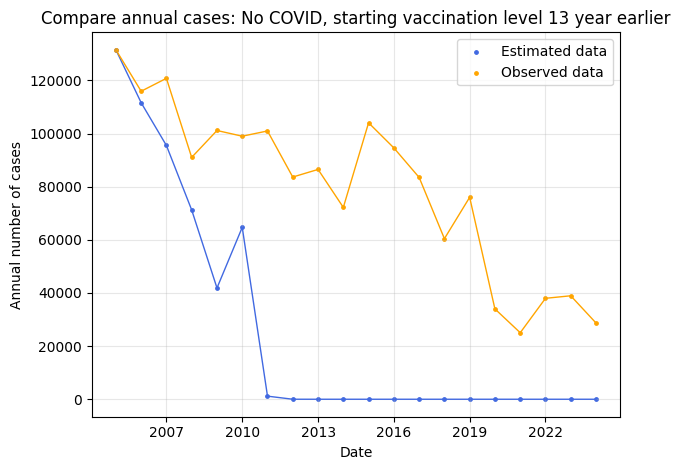

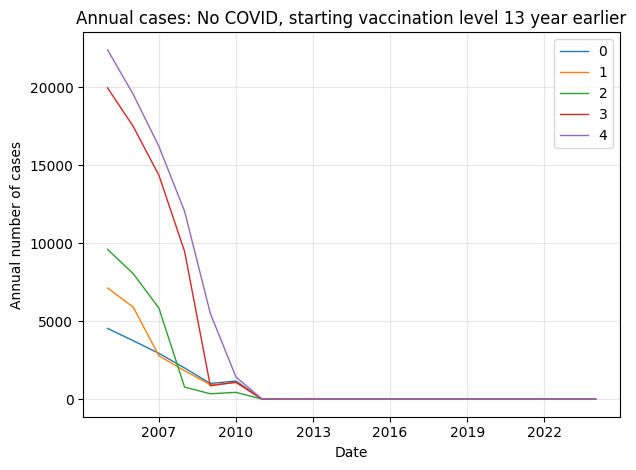

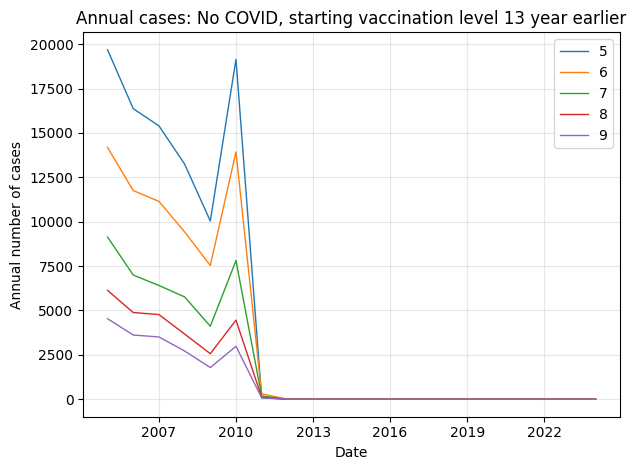

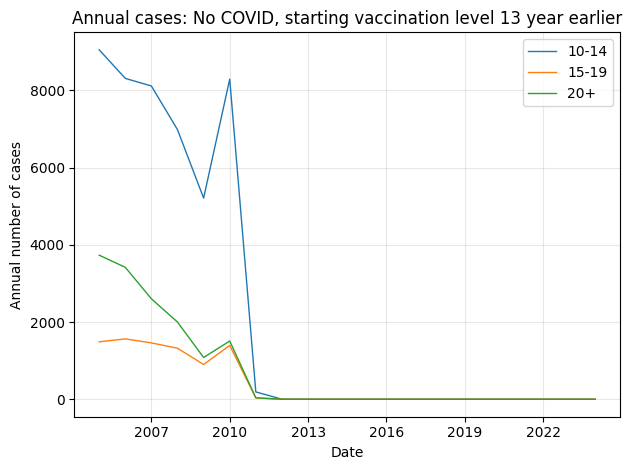

In [89]:
plotting.plot_compare_scenario_to_actual_case(no_cov_13_year_minus.weekly_i_series, no_cov_13_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_13_year_minus.I, 0, 4, no_cov_13_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_13_year_minus.I, 5, 9, no_cov_13_year_minus.name)
plotting.plot_annual_number_of_cases_for_age_groups(no_cov_13_year_minus.I, 10, 12, no_cov_13_year_minus.name)

## Save results

In [90]:
serializable = [
    {
        "name": s.name,
        "S": s.S,
        "I": s.I,
        "V1": s.V1,
        "V2": s.V2
    }
    for s in ALL_SCENARIOS
]

with open("results/no_covid_scenarios.pkl", "wb") as f:
    pickle.dump(serializable, f)